# EJERCICIO 1

## Ganancia de una Call y una Put

## Instrucciones

1. Fijar el precio de ejercicio:

$$
K = 100
$$

2. Generar posibles precios finales de la acción $S(T)$ dentro del intervalo:

$$
S(T) \in [50,200]
$$

3. Calcular la ganancia de una **Call** utilizando:

$$
\text{Ganancia Call} = \max(S(T)-K,0)
$$

4. Calcular la ganancia de una **Put** utilizando:

$$
\text{Ganancia Put} = \max(K-S(T),0)
$$

5. Graficar las ganancias de la **Call** y de la **Put** en función del precio final de la acción $S(T)$.

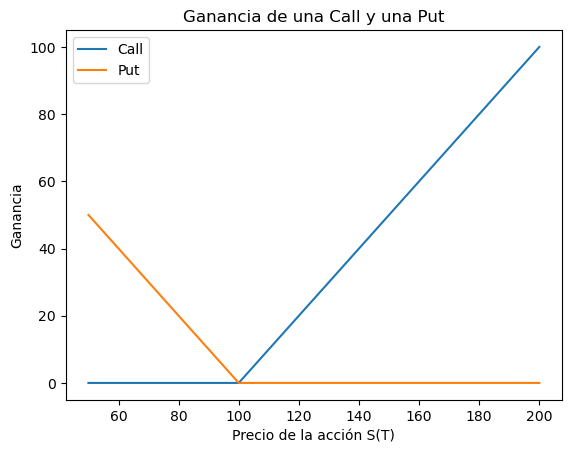

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

K = 100

ST = np.arange(50, 201)

ganancia_call = np.maximum(ST - K, 0)
ganancia_put = np.maximum(K - ST, 0)

plt.plot(ST, ganancia_call, label="Call")
plt.plot(ST, ganancia_put, label="Put")



plt.xlabel("Precio de la acción S(T)")
plt.ylabel("Ganancia")
plt.title("Ganancia de una Call y una Put")
plt.legend()

plt.show()

# EJERCICIO 2


## Parámetros

- $S_0 = 100$
- $K = 100$
- $r = 0.05$
- $\sigma = 0.20$
- $T = 1$
- $M = 10000$ simulaciones

## Instrucciones

1. Simular el precio final de la acción $S(T)$ usando la fórmula:

$$
S(T)=S_0e^{\left(r-\frac{1}{2}\sigma^2\right)T+\sigma\sqrt{T}Z}
$$

donde:

$$
Z \sim N(0,1)
$$

2. Realizar **10,000 simulaciones** del precio final de la acción.

3. Graficar un **histograma de los precios simulados**.

4. Calcular la ganancia de una **Put y Call** con precio de ejercicio:

$$
K=100
$$

La ganancia de la Put y Call se calcula como:

$$
\text{Ganancia Put}=\max(K-S(T),0)
$$
$$
\text{Ganancia Call}=\max(S(T)-K,0)
$$

5. Graficar un **histograma de las ganancias de la Put y Call**.

## SIMULACIÓN

In [17]:
S0=100
K=100
r=.05
V=0.20
T=1
M=10000 # cantidad de simulaciones
import numpy as np
import matplotlib.pyplot as plt
Z= np.random.normal(0,1,size=M)
ST= S0*np.exp((r-0.5*V**2)*T+V*np.sqrt(T)*Z)
ST

array([102.31813753,  93.58910478, 104.15457671, ..., 116.42628574,
       119.52108337, 102.3006337 ])

## GANANCIAS PUT Y CALL

In [18]:
ganancia_put = np.maximum(K - ST, 0)
ganancia_call= np.maximum(ST - K, 0)

## GANANCIAS PROMEDIO

In [19]:
#ganancia promedio
ganancia_put.mean() 

np.float64(5.885505908207786)

In [20]:
ganancia_call.mean()

np.float64(11.054657166145258)

## HISTOGRAMAS

### Put

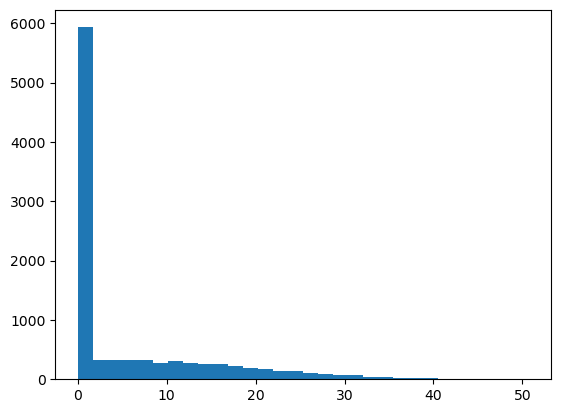

In [21]:
plt.hist(ganancia_put, bins=30)
plt.show()

### Call

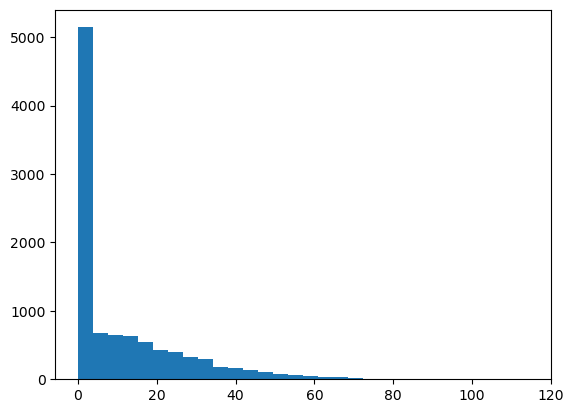

In [22]:
plt.hist(ganancia_call, bins=30)
plt.show()

# EJERCICIO 3.   

#### Comparar cómo cambia la ganancia al aumentar la volatilidad, tasa, tiempo y precio de ejercicio

## VOLATILIDAD

### Put

In [23]:
S0=100
K=100
r=.05
V=0.20
T=1
M=10000 
volatilidades = [0.10, 0.20, 0.40, 0.60]

tabla = []

for V in volatilidades:

    Z = np.random.normal(0, 1, size=M)
    ST= S0*np.exp((r-0.5*V**2)*T+V*np.sqrt(T)*Z)
    ganancia_put = np.maximum(K - ST, 0)

    tabla.append([ V,np.mean(ganancia_put)])

tabla = pd.DataFrame(tabla,columns=["Volatilidad", "Ganancia promedio Put"])

tabla

,Volatilidad,Ganancia promedio Put
0,0.1,2.005389
1,0.2,5.933843
2,0.4,13.910393
3,0.6,21.765104


- **Put:** Al aumentar la volatilidad, la ganancia promedio tiende a aumentar porque hay más posibilidad de que el precio final caiga mucho por debajo de $K$.

### Call

In [24]:
S0=100
K=100
r=.05
V=0.20
T=1
M=10000 
volatilidades = [0.10, 0.20, 0.40, 0.60]

tabla = []

for V in volatilidades:

    Z = np.random.normal(0, 1, size=M)
    ST= S0*np.exp((r-0.5*V**2)*T+V*np.sqrt(T)*Z)
    ganancia_put = np.maximum(ST - K, 0)

    tabla.append([ V,np.mean(ganancia_put)])

tabla = pd.DataFrame(tabla,columns=["Volatilidad", "Ganancia promedio Call"])

tabla

,Volatilidad,Ganancia promedio Call
0,0.1,7.146691
1,0.2,11.057103
2,0.4,19.482843
3,0.6,26.655116


- **Call:** Al aumentar la volatilidad, la ganancia promedio también tiende a aumentar porque hay más posibilidad de que el precio final suba mucho por encima de $K$.

## TASA DE INTERÉS

### Put

In [25]:
S0=100
K=100
r=.05
V=0.20
T=1
M=10000 
tasas = [0.05, 0.10, 0.20]

tabla = []

for r in tasas:

    Z = np.random.normal(0, 1, size=M)
    ST= S0*np.exp((r-0.5*V**2)*T+V*np.sqrt(T)*Z)
    ganancia_put = np.maximum(K - ST, 0)

    tabla.append([ r,np.mean(ganancia_put)])

tabla = pd.DataFrame(tabla,columns=["Tasa", "Ganancia promedio put"])

tabla

,Tasa,Ganancia promedio put
0,0.05,5.808463
1,0.10,4.053544
2,0.20,1.820336


- **Put:** Al aumentar $r$, el precio esperado de la acción tiende a ser mayor, por lo que es menos probable que termine por debajo de $K$ y la ganancia promedio de la Put disminuye.

### Call

In [26]:
S0=100
K=100
r=.05
V=0.20
T=1
M=10000 
tasas = [0.05, 0.10, 0.20]

tabla = []

for r in tasas:

    Z = np.random.normal(0, 1, size=M)
    ST= S0*np.exp((r-0.5*V**2)*T+V*np.sqrt(T)*Z)
    ganancia_put = np.maximum(ST - K, 0)

    tabla.append([ r,np.mean(ganancia_put)])

tabla = pd.DataFrame(tabla,columns=["Tasa", "Ganancia promedio Call"])

tabla

,Tasa,Ganancia promedio Call
0,0.05,11.057056
1,0.10,14.577247
2,0.20,24.170152


- **Call:** Al aumentar $r$, el precio esperado de la acción tiende a subir, por lo que aumenta la posibilidad de terminar por encima de $K$ y la ganancia promedio de la Call aumenta.

## TIEMPO

### Put

In [27]:
S0=100
K=100
r=.05
V=0.20
T=1
M=10000 
tiempos = [0.25, 0.5, 1, 2]

tabla = []

for T in tiempos:

    Z = np.random.normal(0, 1, size=M)
    ST= S0*np.exp((r-0.5*V**2)*T+V*np.sqrt(T)*Z)
    ganancia_put = np.maximum(K - ST, 0)

    tabla.append([ T,np.mean(ganancia_put)])

tabla = pd.DataFrame(tabla,columns=["Tiempo", "Ganancia promedio put"])

tabla

,Tiempo,Ganancia promedio put
0,0.25,3.387305
1,0.50,4.602871
2,1.00,5.911673
3,2.00,7.284685


- **Put:** Al aumentar el tiempo, la ganancia promedio tiende a aumentar.

### Call

In [28]:
S0=100
K=100
r=.05
V=0.20
T=1
M=10000 
tiempos = [0.25, 0.5, 1, 2]

tabla = []

for T in tiempos:

    Z = np.random.normal(0, 1, size=M)
    ST= S0*np.exp((r-0.5*V**2)*T+V*np.sqrt(T)*Z)
    ganancia_put = np.maximum(ST - K, 0)

    tabla.append([ T,np.mean(ganancia_put)])

tabla = pd.DataFrame(tabla,columns=["Tiempo", "Ganancia promedio call"])

tabla

,Tiempo,Ganancia promedio call
0,0.25,4.691711
1,0.50,6.935825
2,1.00,10.966568
3,2.00,17.672873


- **Call:** Al aumentar el tiempo, la ganancia promedio también tiende a aumentar.

## PRECIO DE EJERCICIO

### Put

In [29]:
S0=100
K=100
r=.05
V=0.20
T=1
M=10000 
strikes = [80, 90, 100,110,120]

tabla = []

for K in strikes:

    Z = np.random.normal(0, 1, size=M)
    ST= S0*np.exp((r-0.5*V**2)*T+V*np.sqrt(T)*Z)
    ganancia_put = np.maximum(K - ST, 0)

    tabla.append([ K,np.mean(ganancia_put)])

tabla = pd.DataFrame(tabla,columns=["Precio de ejercicio K", "Ganancia promedio put"])

tabla

,Precio de ejercicio K,Ganancia promedio put
0,80,0.730118
1,90,2.446407
2,100,5.788135
3,110,11.255729
4,120,18.187746


- **Put:** Al aumentar $K$, la ganancia promedio aumenta.

### Call

In [30]:
S0=100
K=100
r=.05
V=0.20
T=1
M=10000 
strikes = [80, 90, 100,110,120]

tabla = []

for K in strikes:

    Z = np.random.normal(0, 1, size=M)
    ST= S0*np.exp((r-0.5*V**2)*T+V*np.sqrt(T)*Z)
    ganancia_put = np.maximum(ST - K, 0)

    tabla.append([ K,np.mean(ganancia_put)])

tabla = pd.DataFrame(tabla,columns=["Precio de ejercicio K", "Ganancia promedio put"])

tabla

,Precio de ejercicio K,Ganancia promedio put
0,80,26.195003
1,90,17.549851
2,100,10.999056
3,110,6.327975
4,120,3.448840


- **Call:** Al aumentar $K$, la ganancia promedio disminuye.